# Plot microstructure profiles

In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\functions\figures'))
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\functions\general_functions'))
from general_functions import read_netCDF_xr, read_matfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.io.matlab import mat_struct

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'  # or any installed font

%matplotlib widget 

### Parameters

Specify the path to the data folder and the date of the campaign:

In [8]:
campaign_name='20251126'
datalevel='Level2'
instrument='VMP' # 'VMP' or 'microCTD'
fileprof=['VMP003_down_prof1'] # List of profile names (without level and extension) 
matstring='down1.0_K5.3_L_NAS0.0058_singlepole_nfft3_EPFL_Goodman' # Name of folders where .mat files are stored
savefig=False # Set to True to save the figure 

# Relative path:
data_folder_rel=os.path.join('..','data',instrument,campaign_name,datalevel)

In [9]:
# Another option if to specify the list of variables to plos as for the CTD profiles:
# varnames_oneprof=["Temp","Cond","sat","Turb","pH","SALIN","rho"]

Set the plot colors:

In [10]:
colplot=plt.get_cmap('tab10',len(fileprof))
white_color_fraction=0.6
whitecol=np.array([1,1,1,1])

### Load the data

netCDF files

In [11]:
dataprof=[]
for kf in range(len(fileprof)):
    if datalevel=='Level1':
        filename_full='L1_'+fileprof[kf]+'.nc'
    elif datalevel=='Level2':
        filename_full='L2_'+fileprof[kf]+'.nc'
    else:
        raise Exception('Wrong level')
        
    dataprof.append(read_netCDF_xr(os.path.join(data_folder_rel,filename_full)))

mat files

In [12]:
datamat=[]
for kf,file in enumerate(fileprof):
    matfolder=file[:file.find('_')]+'_'+matstring
    #matfiles=[f for f in os.listdir(os.path.join(data_folder_rel,matfolder)) if f.endswith(".mat")]
    if datalevel=='Level1':
        matfile='L1_'+file[:file.find('_prof')]+'.mat'
    elif datalevel=='Level2':
        matfile='L2_'+file[:file.find('_prof')]+'.mat'
    else:
        raise Exception('Wrong level')
    
    datamat.append(read_matfile(os.path.join(data_folder_rel,matfolder,matfile)))

### 1. Figure with profile data

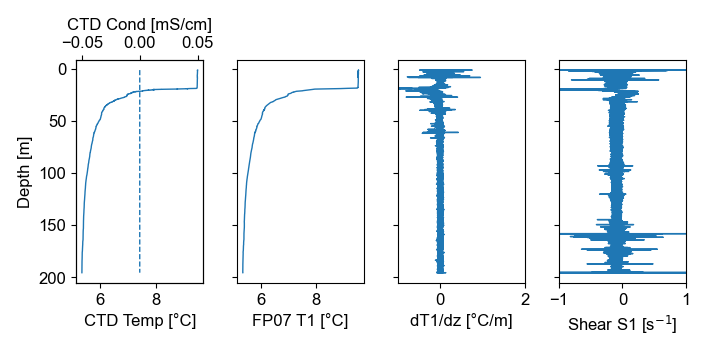

In [13]:
# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


for kf in range(len(dataprof)):
    ax[0].plot(dataprof[kf].SLOW_temperature,dataprof[kf].SLOW_depth,linewidth=1,color=colplot(kf))
    ax0b = ax[0].twiny()
    ax0b.plot(dataprof[kf].SLOW_conductivity/1000,dataprof[kf].SLOW_depth,linewidth=1,linestyle='--',color=colplot(kf))
    
    ax[1].plot(dataprof[kf].FAST_fast_T1.data,dataprof[kf].FAST_depth,linewidth=1,color=colplot(kf))
    
    ax[2].plot(dataprof[kf].FAST_grad_T1.data+2*kf,dataprof[kf].FAST_depth,linewidth=1,color=colplot(kf))
    
    ax[3].plot(dataprof[kf].FAST_fast_S1.data+kf,dataprof[kf].FAST_depth,linewidth=1,color=colplot(kf))


# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('CTD Temp [°C]')
ax0b.set_xlabel('CTD Cond [mS/cm]')
ax[1].set_xlabel('FP07 T1 [°C]')
ax[2].set_xlabel('dT1/dz [°C/m]')
ax[3].set_xlabel('Shear S1 [s$^{-1}$]')

ax[2].set_xlim(-1,2*len(dataprof))
ax[3].set_xlim(-1,len(dataprof))
ax[0].invert_yaxis()

fig.set_tight_layout(True)

Save the figure

In [14]:

if savefig:
    fig.savefig(os.path.join("Figures_turbulence","prof_"+campaign_name+".png"),dpi=400)

### 2. Figure with turbulence data

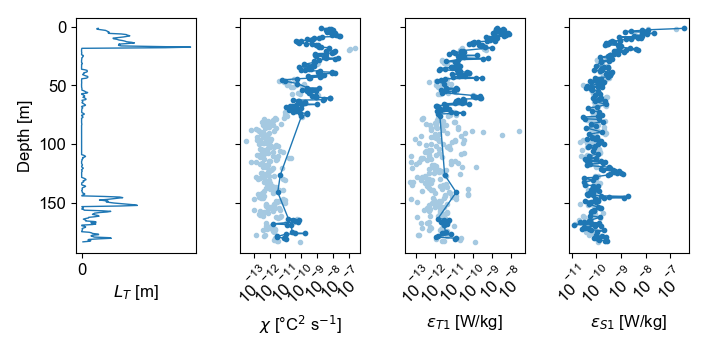

In [15]:
# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


for kf in range(len(dataprof)):
    pale_color = white_color_fraction * whitecol + (1-white_color_fraction) * np.array(colplot(kf))
    
    indkeep_T1=np.where(dataprof[kf].BINNED_flag_T1.data==0)[0]
    indkeep_S1=np.where(dataprof[kf].BINNED_flag_S1.data==0)[0]
    
    ax[0].plot(dataprof[kf].BINNED_LTuT1.data,dataprof[kf].BINNED_depth.data,'-',linewidth=1,color=colplot(kf))
    
    ax[1].plot(dataprof[kf].BINNED_Xi_T1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[1].plot(dataprof[kf].BINNED_Xi_T1.data[indkeep_T1],dataprof[kf].BINNED_depth.data[indkeep_T1],'.-',linewidth=1,color=colplot(kf))
    
    ax[2].plot(dataprof[kf].BINNED_eps_T1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[2].plot(dataprof[kf].BINNED_eps_T1.data[indkeep_T1],dataprof[kf].BINNED_depth.data[indkeep_T1],'.-',linewidth=1,color=colplot(kf))
    
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data[indkeep_S1],dataprof[kf].BINNED_depth.data[indkeep_S1],'.-',linewidth=1,color=colplot(kf))
    
    
# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('$L_T$ [m]')
ax[1].set_xlabel('$\\chi$ [°C$^2$ s$^{-1}$]')
ax[2].set_xlabel('$\\varepsilon_{T1}$ [W/kg]')
ax[3].set_xlabel('$\\varepsilon_{S1}$ [W/kg]')

xlimval=ax[0].get_xlim()
ax[0].set_xticks(np.arange(0, 100, 10))
ax[0].set_xlim(xlimval)

ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, -5, 1))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)

ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, -5, 1))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)

ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, -5, 1))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)

ax[0].invert_yaxis()

fig.set_tight_layout(True)


Save the figure:

In [16]:
if savefig:
    fig.savefig(os.path.join("Figures_turbulence","prof_turb_"+campaign_name+".png"),dpi=400)

### 3. Figure spectrum

In [26]:
indfile=0 # index of the netCDF file
depth_spec=50 # [m]
Tlimval=[1e-10,1e0]
Slimval=[1e-10,1e0]


In [27]:
def get_spec_data(datamat,indfile,indprof,ind_bin,name_spec):
    if indprof==0 and type(datamat[indfile]['BINNED'])==dict:
        spec_data=datamat[indfile]['BINNED'][name_spec][ind_bin]
    elif type(datamat[indfile]['BINNED'])==list:
        spec_data=datamat[indfile]['BINNED'][indprof][name_spec][ind_bin]
    else:
        raise Exception('Wrong format for BINNED in mat file')
    return spec_data

In [69]:
def plot_specT(ax,specT,Tlimval,epsT,name):
    ax.loglog(specT['k0'],specT['PSD_raw'],'-',color='black',label='Raw spectrum')
    ax.loglog(specT['k0'],specT['PSD0'],'-',color='C0',label='Corrected spectrum')
    ax.loglog(specT['k'][specT['ind_fit']],specT['PSD'][specT['ind_fit']],'o',color='C0',label='Spectrum for fitting')
    ax.loglog(specT['k0'],specT['Sn0'],':',color='k',label='Noise spectrum')
    ax.loglog(specT['k0'],specT['PSD_theo'],'-',color='red',label='Theoretical spectrum')
    ax.loglog(specT['k'][specT['ind_fit']],specT['Sm'][specT['ind_fit']]+specT['Sn'][specT['ind_fit']],':',color='red',linewidth=2,label='Power spectrum')

    ax.plot(specT['kn'],Tlimval[0],'^',color=[0.5,0.5,0.5],markersize=8,label='$k_n$')
    ax.plot(specT['kP'],Tlimval[0],'^',color='C0',markersize=8,label='$k_P$')
    ax.plot(specT['kSNR'],Tlimval[0],'^',color='k',markersize=8,label='$k_{SNR}$')
    ax.plot(specT['kB'],Tlimval[0],'^',color='r',markersize=8,label='$k_B$')
    ax.plot(specT['kH'],Tlimval[0],'^',color='w',markeredgecolor='k',markersize=8,label='$k_H$')
    
    text_eps='$\\varepsilon_{{{}}} $ = {:.1e} W/kg'.format(name,epsT)
    ax.text(10**0.5,10**-1,text_eps,color='C0',fontsize=10)
   
    ax.set_ylim(Tlimval[0],Tlimval[1])

def plot_specS(ax,specS,Slimval,epsS,name):
    ax.loglog(specS['k'],specS['PSD0'],'-',color='black',label='Corrected spectrum')
    ax.loglog(specS['k'],specS['PSD'],'-',color='C1',label='Corrected and denoised corrected')
    ax.loglog(specS['k'][specS['ind_fit']],specS['PSD'][specS['ind_fit']],'o',color='C1',label='Spectrum for fitting')
    ax.loglog(specS['k'],specS['PSD_theo'],'-',color='red',label='Theoretical spectrum')
    
    ax.plot(specS['kn'],Slimval[0],'^',color=[0.5,0.5,0.5],markersize=8,label='$k_n$')
    ax.plot(specS['kK'],Slimval[0],'^',color='r',markersize=8,label='$k_K$')
    ax.plot(specS['k_lim'],Slimval[0],'^',color='w',markeredgecolor='k',markersize=8,label='$k_{lim}$')
    
    text_eps='$\\varepsilon_{{{}}} $ = {:.1e} W/kg'.format(name,epsS)
    ax.text(10**0.5,10**-1,text_eps,color='C1',fontsize=10)
    ax.set_ylim(Slimval[0],Slimval[1])

In [70]:
ind_bin=np.where(dataprof[indfile].BINNED_depth.data>=depth_spec)[0][0]
depth_bin=dataprof[indfile].BINNED_depth.data[ind_bin]
indprof=int(fileprof[indfile][fileprof[indfile].find('_prof')+5:])-1
plot_specT1=False
plot_specT2=False
plot_specS1=False
plot_specS2=False
if 'SPECTRUMT1' in datamat[indfile]['BINNED'].keys():
    specT1=get_spec_data(datamat,indfile,indprof,ind_bin,'SPECTRUMT1')
    plot_specT1=True
if 'SPECTRUMT2' in datamat[indfile]['BINNED'].keys(): 
    specT2=get_spec_data(datamat,indfile,indprof,ind_bin,'SPECTRUMT2')
    plot_specT2=True
if 'SPECTRUMS1' in datamat[indfile]['BINNED'].keys(): 
    specS1=get_spec_data(datamat,indfile,indprof,ind_bin,'SPECTRUMS1')
    plot_specS1=True
if 'SPECTRUMS2' in datamat[indfile]['BINNED'].keys(): 
    specS2=get_spec_data(datamat,indfile,indprof,ind_bin,'SPECTRUMS2')
    plot_specS2=True

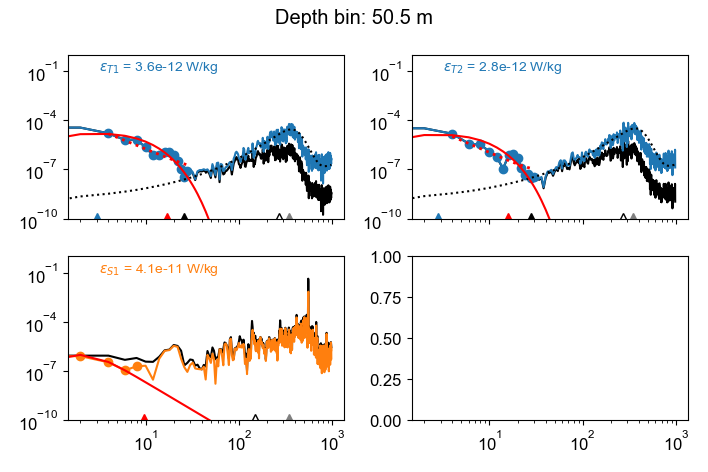

In [72]:
# Create a figure with specified size in centimeters
fig,ax = plt.subplots(2,2,figsize=(18 / 2.54, 12 / 2.54),sharex=True)  # Convert from cm to inches

# Temperature spectrum:
if plot_specT1:
    plot_specT(ax[0,0],specT1,Tlimval,epsT=dataprof[indfile].BINNED_eps_T1.data[ind_bin],name='T1')
    
if plot_specT2:
    plot_specT(ax[0,1],specT2,Tlimval,epsT=dataprof[indfile].BINNED_eps_T2.data[ind_bin],name='T2')

# Shear spectrum:
if plot_specS1:
    plot_specS(ax[1,0],specS1,Slimval,epsS=dataprof[indfile].BINNED_eps_S1.data[ind_bin],name='S1') 

if plot_specS2:
    plot_specS(ax[1,1],specS2,Slimval,epsS=dataprof[indfile].BINNED_eps_S2.data[ind_bin],name='S2')

fig.suptitle('Depth bin: '+str(round(depth_bin*10)/10)+' m')

fig.set_tight_layout(True)

if savefig:
    fig.savefig(os.path.join("Figures_turbulence","spec_"+campaign_name+"_prof_"+
                             fileprof[indfile]+"_depth_"+str(depth_bin)+"m.png"),dpi=400)